# Analysis for the $\sin$ benchmark

The datasets are created as follows.

1. `sin-noise-0`:
    Each $x_j$ is selected uniformly at random between $-\pi$ and $\pi$, $j = 1 \dots 100$.
    Then $y_j = \sin x_j$.
2. `sin-noise-1`:
    Same process as `sin-noise-0` but $y_j = \sin x_j + \eta_j$ where $\eta_j$ has a normal distribution with mean $0$ and standard deviation $0.1$.
3. `sin-noise-2`:
    Same process as `sin-noise-1` but the standard deviation is $0.01$.
4. `sin-wide-noise-k`:
    Same processes as `sin-noise-k` but with $x_j$ drawn uniformly between $-2\pi$ and $2\pi$, $j = 1 \dots 200$.


## Prelude

In [23]:
import numpy as np
import pandas as pd
import seaborn as sns
import sympy

## Loading data

These are the datasets to be fit.

In [5]:
sn0 = pd.read_csv("datasets/sin-noise-0.csv")
sn1 = pd.read_csv("datasets/sin-noise-1.csv")
sn2 = pd.read_csv("datasets/sin-noise-2.csv")
sw0 = pd.read_csv("datasets/sin-wide-noise-0.csv")
sw1 = pd.read_csv("datasets/sin-wide-noise-1.csv")
sw2 = pd.read_csv("datasets/sin-wide-noise-2.csv")

<Axes: xlabel='x', ylabel='y'>

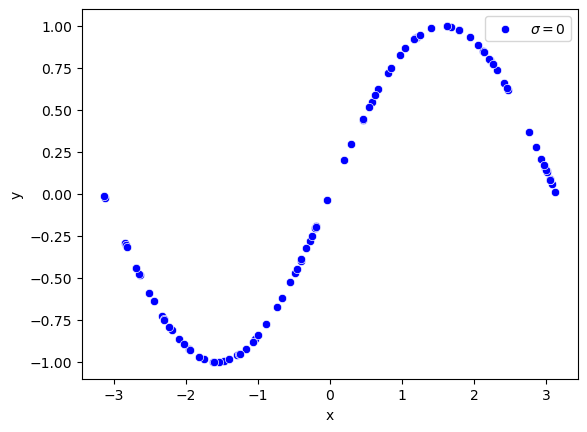

In [17]:
sns.scatterplot(data=sn0, x="x", y="y", color="blue", label=r"$\sigma= 0$")

<Axes: xlabel='x', ylabel='y'>

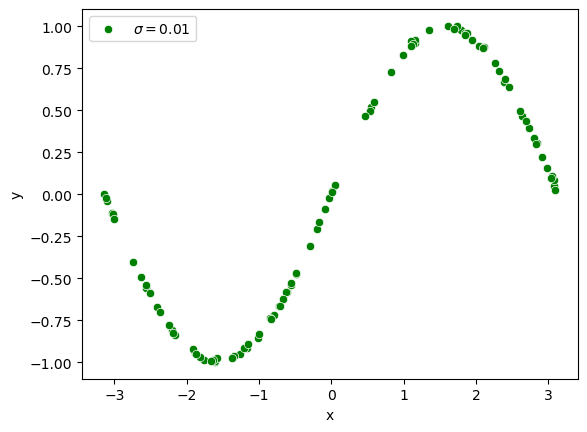

In [18]:
sns.scatterplot(data=sn2, x="x", y="y", color="green", label=r"$\sigma = 0.01$")

<Axes: xlabel='x', ylabel='y'>

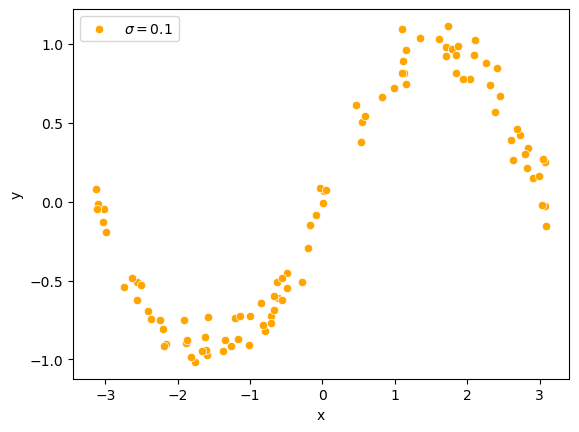

In [19]:
sns.scatterplot(data=sn1, x="x", y="y", color="orange", label=r"$\sigma = 0.1$")

<Axes: xlabel='x', ylabel='y'>

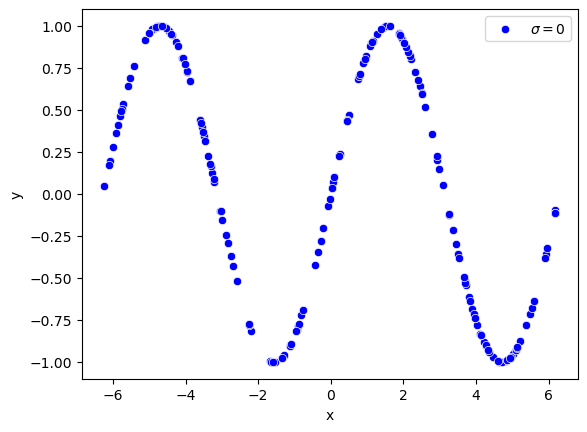

In [20]:
sns.scatterplot(data=sw0, x="x", y="y", color="blue", label=r"$\sigma= 0$")

<Axes: xlabel='x', ylabel='y'>

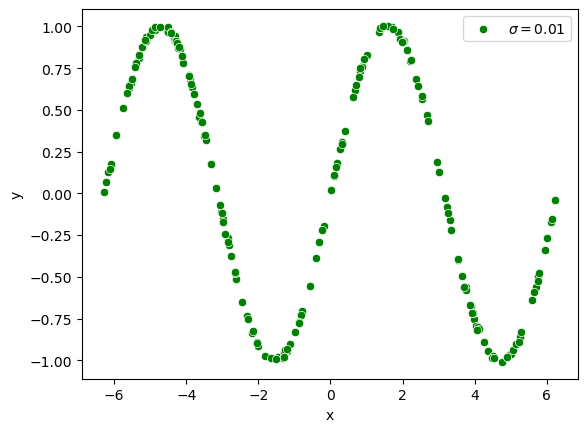

In [21]:
sns.scatterplot(data=sw2, x="x", y="y", color="green", label=r"$\sigma = 0.01$")

<Axes: xlabel='x', ylabel='y'>

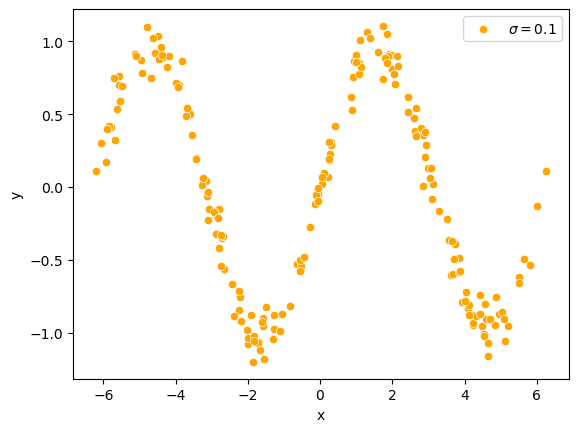

In [22]:
sns.scatterplot(data=sw1, x="x", y="y", color="orange", label=r"$\sigma = 0.1$")

These are the results of Jessamine symbolic regression.

In [25]:
full_report = pd.read_csv("Generated/full-report.csv")

In [26]:
full_report

,run_set,data_set,sample_num,rating,mse,expr_original_syms,expr
0,SRB-2026-06-25-1715,sin-noise-0,1,3.000000e-12,2.092860e-28,0.999999999999979*sin(x) - 8.061000800782363e-17,0.999999999999979*sin(x1) - 8.061000800782363e-17
1,SRB-2026-06-25-1715,sin-noise-0,2,2.000000e-12,2.092210e-28,0.999999999999979*sin(x),0.999999999999979*sin(x1)
2,SRB-2026-06-25-1715,sin-noise-0,3,3.000000e-12,2.092860e-28,0.999999999999979*sin(x) - 8.04410249348464e-17,0.999999999999979*sin(x1) - 8.04410249348464e-17
3,SRB-2026-06-25-1715,sin-noise-0,4,2.500003e-12,4.762521e-29,0.9999999999999896*sin(x) - 4.38645111787971e-17,0.9999999999999896*sin(x1) - 4.38645111787971e-17
4,SRB-2026-06-25-1715,sin-noise-0,5,2.000000e-12,2.092860e-28,0.999999999999979*sin(x) - 8.028855900434062e-17,0.999999999999979*sin(x1) - 8.028855900434062e-17
...,...,...,...,...,...,...,...
187,SRB-2026-06-25-1715,sin-wide-noise-2,28,7.655117e-05,7.655107e-05,0.00024704537363603877*x*(sin(x + (x - 0.00576...,0.00024704537363603877*x1*(sin(x1 + (x1 - 0.00...
188,SRB-2026-06-25-1715,sin-wide-noise-2,29,7.675574e-05,7.674867e-05,-0.00055997819593047512*x + 1.1826926673452221...,-0.00055997819593047512*x1 + 1.182692667345222...
189,SRB-2026-06-25-1715,sin-wide-noise-2,30,7.536945e-05,7.536941e-05,2.6739008553623964e-10*(-x - (0.00736197631698...,2.6739008553623964e-10*(-x1 - (0.0073619763169...
190,SRB-2026-06-25-1715,sin-wide-noise-2,31,7.748349e-05,7.748084e-05,-9.332446068630301e-7*x**3 + 4.621327987941744...,-9.332446068630301e-7*x1**3 + 4.62132798794174...


## Analysis of results from the narrow datasets